# Experiment: EMG2QWERTY Data Inspection

Goal: inspect how raw session data and labels are represented using only `emg2qwerty/data.py` and `emg2qwerty/transforms.py`, so we can decide preprocessing/model input strategies next.

This notebook will:
- load one `.hdf5` session from `Data/` with `EMGSessionData`
- inspect structured raw fields, timestamps, metadata, and ground-truth labels
- run baseline transforms (`ToTensor`, `TemporalAlignmentJitter`, `LogSpectrogram`)
- inspect windowed samples from `WindowedEMGDataset`


In [25]:
from __future__ import annotations

import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import torch
import matplotlib.pyplot as plt

# Make notebook robust to being launched from repo root OR preprocessing/.
ROOT = Path.cwd().resolve()
if not (ROOT / "emg2qwerty").exists() and (ROOT.parent / "emg2qwerty").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from emg2qwerty.data import EMGSessionData, WindowedEMGDataset
from emg2qwerty.transforms import Compose, LogSpectrogram, TemporalAlignmentJitter, ToTensor

DATA_DIR = ROOT / "Data"
assert DATA_DIR.exists(), f"Expected data directory at: {DATA_DIR}"
print(f"Repo root: {ROOT}")
print(f"Data dir:  {DATA_DIR}")


Repo root: /Users/shervin/Desktop/Ece147-Final
Data dir:  /Users/shervin/Desktop/Ece147-Final/Data


## 1) Discover Session Files
Pick a session index to inspect.


In [26]:
session_paths = sorted(DATA_DIR.glob("*.hdf5"))
print(f"Found {len(session_paths)} session files.")
for i, path in enumerate(session_paths[:10]):
    print(f"[{i:02d}] {path.name}")

session_idx = 0  # change this to inspect another session
session_path = session_paths[session_idx]
print(f"\nSelected session: {session_path.name}")


Found 18 session files.
[00] 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[01] 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[02] 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[03] 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[04] 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[05] 2021-06-03-1622766673-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[06] 2021-06-04-1622861066-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[07] 2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[08] 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
[09] 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5

Selected session: 2021-06-02-1622679967-keystrokes-dca-

## 2) Inspect Raw Session Structure (`EMGSessionData`)
This shows what is physically stored in one `.hdf5` file.


In [27]:
with EMGSessionData(session_path) as session:
    print(session)
    print("-" * 80)
    print(f"fields: {session.fields}")
    print(f"condition: {session.condition}")
    print(f"user: {session.user}")
    print(f"duration_mins metadata: {session.duration_mins:.3f}")
    print(f"num keystrokes: {len(session.keystrokes)}")
    print(f"num prompts: {len(session.prompts)}")

    ts = session.timestamps
    dt = np.diff(ts)
    print("-" * 80)
    print(f"timestamps shape: {ts.shape}")
    print(f"time range: [{ts[0]:.6f}, {ts[-1]:.6f}] sec (unix time)")
    print(f"mean dt: {dt.mean():.6f} sec -> ~{1.0 / dt.mean():.1f} Hz")
    print(f"median dt: {np.median(dt):.6f} sec -> ~{1.0 / np.median(dt):.1f} Hz")

    raw_head = session[:5]
    print("-" * 80)
    print("raw_head dtype:")
    print(raw_head.dtype)
    print(f"raw_head shape: {raw_head.shape}")
    print(f"emg_left head shape:  {raw_head[EMGSessionData.EMG_LEFT].shape}")
    print(f"emg_right head shape: {raw_head[EMGSessionData.EMG_RIGHT].shape}")
    print(f"time head: {raw_head[EMGSessionData.TIMESTAMPS]}")

    print("-" * 80)
    print("first keystroke entry:")
    pprint(session.keystrokes[0])
    print("first prompt entry:")
    pprint(session.prompts[0])


EMGSessionData 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f: (2376900 EMG samples, 4690 keystrokes, 19.81 mins)
--------------------------------------------------------------------------------
fields: ['emg_right', 'time', 'emg_left']
condition: on_keyboard
user: 89335547
duration_mins metadata: 19.808
num keystrokes: 4690
num prompts: 154
--------------------------------------------------------------------------------
timestamps shape: (2376900,)
time range: [1622679967.279221, 1622681155.735224] sec (unix time)
mean dt: 0.000500 sec -> ~2000.0 Hz
median dt: 0.000500 sec -> ~2000.1 Hz
--------------------------------------------------------------------------------
raw_head dtype:
[('emg_right', '<f4', (16,)), ('time', '<f8'), ('emg_left', '<f4', (16,))]
raw_head shape: (5,)
emg_left head shape:  (5, 16)
emg_right head shape: (5, 16)
time head: [1.62267997e+09 1.62267997e+09 1.62267997e+09 1.62267997e+09
 1.62267997e+09]
----------------------------

## 3) Visualize a Small Raw EMG Window
Quick sanity check of waveform shape and amplitude for one left/right channel pair.


window samples: 1001
left shape:  (1001, 16)
right shape: (1001, 16)


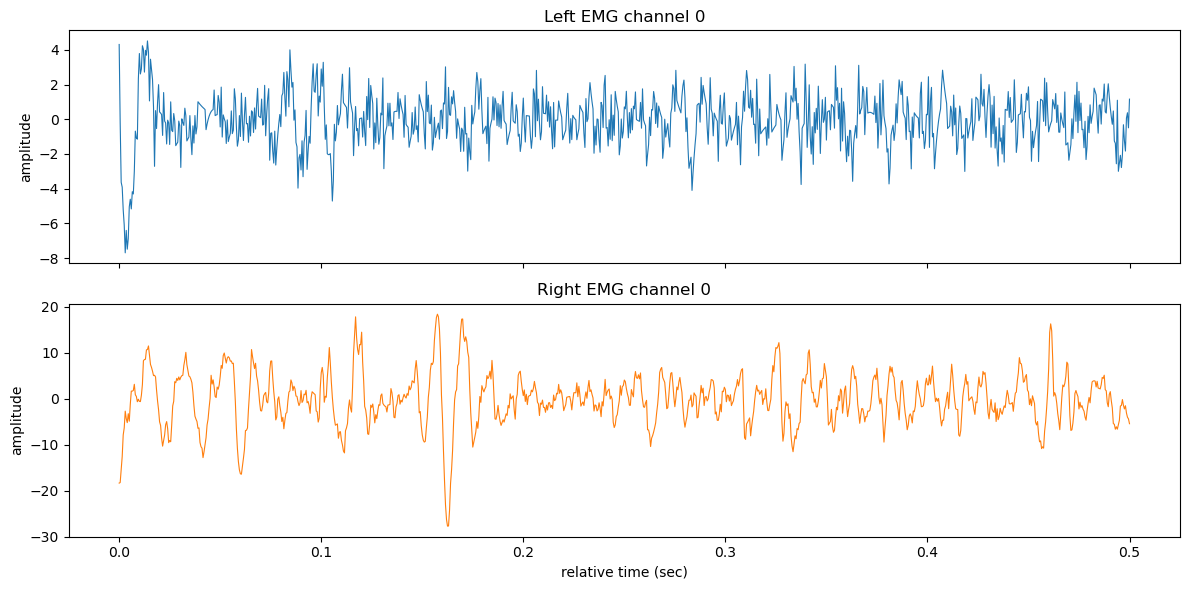

In [47]:
seconds_to_plot = 0.5
channel = 0

with EMGSessionData(session_path) as session:
    t0 = session.timestamps[3]
    window = session.slice(start_t=t0, end_t=t0 + seconds_to_plot)

left = window[EMGSessionData.EMG_LEFT]
right = window[EMGSessionData.EMG_RIGHT]
rel_t = window[EMGSessionData.TIMESTAMPS] - window[EMGSessionData.TIMESTAMPS][0]

print(f"window samples: {len(window)}")
print(f"left shape:  {left.shape}")
print(f"right shape: {right.shape}")

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(rel_t, left[:, channel], linewidth=0.8)
ax[0].set_title(f"Left EMG channel {channel}")
ax[0].set_ylabel("amplitude")
ax[1].plot(rel_t, right[:, channel], linewidth=0.8, color="tab:orange")
ax[1].set_title(f"Right EMG channel {channel}")
ax[1].set_ylabel("amplitude")
ax[1].set_xlabel("relative time (sec)")
plt.tight_layout()
plt.show()


## 4) Inspect Ground Truth Extraction (`ground_truth`)
This is the exact label path used by `WindowedEMGDataset` for training targets.


In [29]:
label_window_secs = 5.0

with EMGSessionData(session_path) as session:
    start_t = session.timestamps[0]
    end_t = start_t + label_window_secs
    label_data = session.ground_truth(start_t=start_t, end_t=end_t)

print(f"text length: {len(label_data.text)}")
print(f"first 200 chars (repr): {repr(label_data.text[:200])}")
print(f"labels shape: {label_data.labels.shape}")
print(f"first 40 labels: {label_data.labels[:40]}")
print(f"has char timestamps: {label_data.timestamps is not None}")
if label_data.timestamps is not None:
    print(f"first 10 label timestamps: {label_data.timestamps[:10]}")


text length: 0
first 200 chars (repr): ''
labels shape: (0,)
first 40 labels: []
has char timestamps: True
first 10 label timestamps: []


## 5) Inspect Transform Outputs (`transforms.py`)
Start with `ToTensor`, then inspect jitter and log-spectrogram output shape.


In [30]:
window_length = 2000

with EMGSessionData(session_path) as session:
    raw_window = session[:window_length]

to_tensor = ToTensor()
emg_tensor = to_tensor(raw_window)
print(f"ToTensor output shape: {tuple(emg_tensor.shape)} (T, hand, channels)")
print(f"ToTensor dtype: {emg_tensor.dtype}")

jitter = TemporalAlignmentJitter(max_offset=8)
jittered = jitter(emg_tensor)
print(f"TemporalAlignmentJitter output shape: {tuple(jittered.shape)}")

spec_transform = Compose([ToTensor(), LogSpectrogram(n_fft=64, hop_length=16)])
spec = spec_transform(raw_window)
print(f"LogSpectrogram output shape: {tuple(spec.shape)} (T, hand, channels, freq)")
print(f"LogSpectrogram dtype: {spec.dtype}")


ToTensor output shape: (2000, 2, 16) (T, hand, channels)
ToTensor dtype: torch.float32
TemporalAlignmentJitter output shape: (1998, 2, 16)
LogSpectrogram output shape: (122, 2, 16, 33) (T, hand, channels, freq)
LogSpectrogram dtype: torch.float32


## 6) Inspect `WindowedEMGDataset` Samples
This simulates what training sees for inputs and labels.


In [31]:
dataset = WindowedEMGDataset(
    hdf5_path=session_path,
    window_length=4000,
    stride=2000,
    padding=(200, 200),
    jitter=False,
    transform=ToTensor(),
)

print(f"dataset length: {len(dataset)} windows")

sample_emg, sample_labels = dataset[0]
print(f"sample input shape: {tuple(sample_emg.shape)}")
print(f"sample labels shape: {tuple(sample_labels.shape)}")
print(f"first 40 sample labels: {sample_labels[:40]}")

n = min(4, len(dataset))
batch = WindowedEMGDataset.collate([dataset[i] for i in range(n)])
print("\nCollated batch shapes:")
for k, v in batch.items():
    print(f"- {k}: {tuple(v.shape)}")


dataset length: 1187 windows
sample input shape: (4200, 2, 16)
sample labels shape: (0,)
first 40 sample labels: tensor([], dtype=torch.int32)

Collated batch shapes:
- inputs: (4400, 4, 2, 16)
- targets: (0, 4)
- input_lengths: (4,)
- target_lengths: (4,)


## 7) What to Compare Next
After running this notebook on a few sessions/users, decide model input options to test:
- raw time-domain (`ToTensor`)
- log-spectrogram (`ToTensor + LogSpectrogram`)
- augmentation toggles (`TemporalAlignmentJitter`, `RandomBandRotation`, `SpecAugment`)
- window lengths/strides and padding effects on label density
